In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

In [2]:
from helper import plot_map, from_upper_triu, upper_triangular_to_vector_skip_diagonals

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [5]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1003715/ipykernel_4043843/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [ ]:
# Load the entire model (architecture + weights)
# model = torch.load("/home1/smaruj/pytorch_akita/model.pth")

In [ ]:
# model = model.to(device)

In [ ]:
# Set the model to evaluation mode (important for inference)
# model.eval()

In [6]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1310720), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 1, 130305]            --
├─StochasticReverseComplement: 1-1       [2, 4, 1310720]           --
├─StochasticShift: 1-2                   [2, 4, 1310720]           --
├─ConvBlock: 1-3                         [2, 128, 655360]          --
│    └─Conv1d: 2-1                       [2, 128, 1310720]         7,680
│    └─BatchNorm1d: 2-2                  [2, 128, 1310720]         256
│    └─MaxPool1d: 2-3                    [2, 128, 655360]          --
├─ConvTower: 1-4                         [2, 128, 640]             --
│    └─Sequential: 2-4                   [2, 128, 640]             --
│    │    └─ReLU: 3-1                    [2, 128, 655360]          --
│    │    └─Conv1d: 3-2                  [2, 128, 655360]          81,920
│    │    └─BatchNorm1d: 3-3             [2, 128, 655360]          256
│    │    └─MaxPool1d: 3-4               [2, 128, 327680]          --
│    │

In [7]:
X = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/X.pt", weights_only=True)

In [8]:
y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/boundary_-0.5.pt", weights_only=True)

In [9]:
# to ensure the local, forked ledidi is used
# not the one installed using pip

import sys
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")  # Add the directory where "ledidi" is located
from ledidi_whole_seq import Ledidi

In [10]:
X.shape, y_bar.shape

(torch.Size([1, 4, 1310720]), torch.Size([1, 1, 130305]))

In [11]:
wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),   # output_loss=torch.nn.MSELoss(),
                 batch_size=1,
                 l=0.2,
                 max_iter=3000,
                 early_stopping_iter=3000,
                 return_history=True,
                 verbose=True
                 ).cuda()

Model in train mode: False
Gradients enabled for weights: True
Weights shape: torch.Size([1, 4, 1310720])


In [ ]:
# slice_torch = X[:,:,start_index : end_index]

In [ ]:
# X_l_flank = X[:,:,start_index - 2048*2 : start_index]
# X_r_flank = X[:,:,end_index : end_index + 2048*2]

In [ ]:
# x_bar, history = wrapper.fit_transform(X, modified_vector_tensor)
# if use_semifreddo=True
# x_bar = wrapper.fit_transform(slice_torch, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)
# x_bar, history = wrapper.fit_transform(slice_torch, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)

In [12]:
# if use_semifreddo=False
# x_bar = wrapper.fit_transform(X, y_bar)
x_bar, history = wrapper.fit_transform(X, y_bar)

y_hat shape torch.Size([1, 1, 130305])
y_bar shape torch.Size([1, 1, 130305])
Global loss applied.
X_ shape torch.Size([1, 4, 1310720])
y_bar shape torch.Size([1, 1, 130305])
iter=I	input_loss=0.0	output_loss=3.277e+04	total_loss=3.277e+04	time=0.0
iter=100	input_loss=1.35e+05	output_loss=4.531e+03	total_loss=3.154e+04	time=12.2
iter=200	input_loss=1.101e+05	output_loss=3.689e+03	total_loss=2.571e+04	time=12.14
iter=300	input_loss=1.282e+05	output_loss=3.773e+03	total_loss=2.941e+04	time=12.15
iter=400	input_loss=1.448e+05	output_loss=3.868e+03	total_loss=3.283e+04	time=12.16
iter=500	input_loss=1.6e+05	output_loss=2.842e+03	total_loss=3.484e+04	time=12.17
iter=600	input_loss=1.75e+05	output_loss=3.401e+03	total_loss=3.839e+04	time=12.18
iter=700	input_loss=1.819e+05	output_loss=3.05e+03	total_loss=3.943e+04	time=12.19
iter=800	input_loss=1.862e+05	output_loss=2.895e+03	total_loss=4.014e+04	time=12.19
iter=900	input_loss=1.92e+05	output_loss=4.546e+03	total_loss=4.294e+04	time=12.19
it

In [ ]:
x_bar

## Input and Output Loss Plots

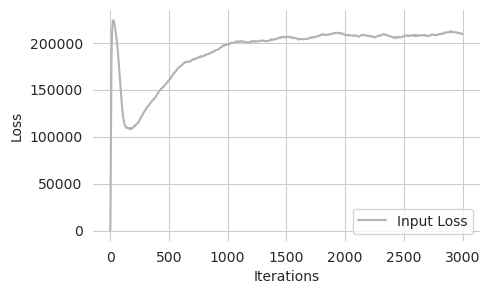

In [13]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

plt.figure(figsize=(5, 3))
plt.plot(history['input_loss'], c='0.7', label="Input Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

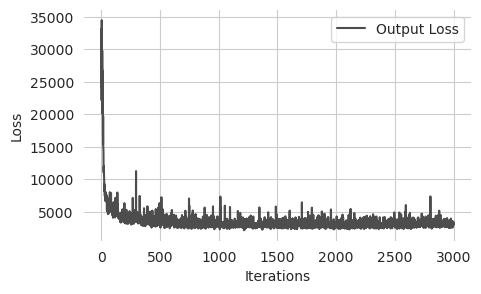

In [14]:
plt.figure(figsize=(5, 3))
plt.plot(history['output_loss'], c='0.3', label="Output Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

In [15]:
seq1_indices = torch.argmax(x_bar, dim=1)
seq2_indices = torch.argmax(X, dim=1)

In [16]:
num_differences = (seq1_indices != seq2_indices).sum().item()

print(f"Number of differing nucleotides: {num_differences}")

Number of differing nucleotides: 108732


## Plotting edits

In [ ]:
X_new = x_bar.clone()

In [ ]:
unique_set = set()

smallest_edited_location = 1310720
biggest_edited_location = 0

for i in range(1):

    print("sequence:", i)
    
    difference_vector = (X[0, :, :] == X_new[i, :, :]).all(dim=0).cpu().numpy()

    e=0
    edits_loc = []

    for loc_index in range(len(difference_vector)):
        if difference_vector[loc_index] == False:
            e += 1
            edits_loc.append(loc_index)
            if loc_index < smallest_edited_location:
                smallest_edited_location = loc_index
            if loc_index > biggest_edited_location:
                biggest_edited_location = loc_index
    
    edits_tuple = tuple(edits_loc)

    if edits_tuple not in unique_set:
        unique_set.add(edits_tuple)
    
    # print("number of edits:", e)
    # print("edits locations:", edits_loc)

In [ ]:
import numpy as np

In [ ]:
edits_tuple[-1] - edits_tuple[0]

In [ ]:
edits_array = np.array(edits_tuple) 
bins_array = edits_array // 2048

In [ ]:
bin_counts = np.bincount(bins_array)

In [ ]:
len(bin_counts)

In [ ]:
filtered_bins = np.arange(640)
filtered_counts = bin_counts[filtered_bins]

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(filtered_bins, filtered_counts)
plt.xlabel("Bin Index")
plt.ylabel("Count")
plt.title("Bin Counts")
plt.show()

In [ ]:
len(unique_set)

In [ ]:
import seaborn as sns
import numpy as np

## CTCF & CTCF-flanks PWM score

In [ ]:
# CTCF PWM
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

# CTCF with strong flanks (15bp)
CTCF_flanks = "/home1/smaruj/IterativeMutagenesis/PWM_with_flanks.npy"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [ ]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCFflanks = np.load(CTCF_flanks)

In [ ]:
def pwm_convolution(pwm, sequence):
    len_pwm, _ = pwm.shape
    len_seq, _ = sequence.shape
    conv_scores = []
    
    # Sliding window over the sequence matrix
    for i in range(len_seq - len_pwm + 1):
        # Extract submatrix (window) of the sequence of size len_pwm x 4
        window = sequence[i:i+len_pwm, :]
        
        # Compute the dot product (element-wise multiplication and sum) for the window
        score = np.sum(pwm * window)
        conv_scores.append(score)
    
    # Return the maximum convolution score
    return conv_scores


def reverse_complement_pwm(pwm):
    """Get the reverse complement of a given PWM."""
    # Reverse the rows (i.e., reverse the motif) and swap A<->T (0<->3) and C<->G (1<->2)
    rev_comp_pwm = pwm[::-1, :][:, [3, 2, 1, 0]]
    return rev_comp_pwm


In [ ]:
x_bar_np = x_bar[:, :, :].cpu().detach().numpy().transpose(0, 2, 1)

In [ ]:
308 * 2048

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_np[0, 270336:272384, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_np[0, 270336:272384, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 1st slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_np[0, 628736:630784, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_np[0, 628736:630784, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 2nd slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_np[0, 270336:272384, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_np[0, 270336:272384, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_np[0, 628736:630784, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_np[0, 628736:630784, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

## Predicted Maps

In [17]:
model.eval()
with torch.no_grad():
    pred = model(x_bar)

In [18]:
pred.shape

torch.Size([1, 1, 130305])

In [19]:
matrix_to_plot = from_upper_triu(pred[0, 0, :], matrix_len=512, num_diags=2)

In [20]:
import numpy as np

In [21]:
np.nanmean(matrix_to_plot[:256,256:])

-0.5082188676028336

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

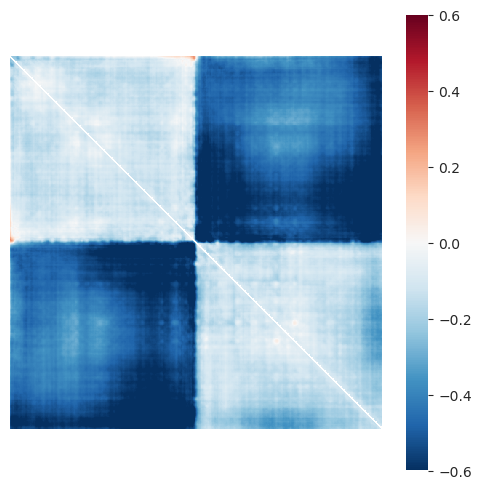

In [23]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

fig, axes = plt.subplots(1, 1, figsize=(width, height))

sns.heatmap(
    matrix_to_plot,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cmap=palette,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes
)

# # Highlight the 194th row
# axes.hlines(y=256, xmin=0, xmax=512, colors='black', linewidth=1.5)

# # Highlight the 254th column
# axes.vlines(x=256, ymin=0, ymax=512, colors='black', linewidth=1.5)

plt.tight_layout()
plt.show()